In [1]:
import numpy as np
import pandas as pd
import scipy as scipy
from copy import deepcopy
import math
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from scipy.stats import t, chi2, f, norm, poisson, binom, uniform, expon, logistic
import seaborn

In [2]:
np.random.seed(123)
n = 100000

In [3]:
income = np.exp(norm.rvs(size = n, loc = 11.1, scale = 0.5))

In [4]:
age = norm.rvs(size = n, loc = 35, scale = 10)

age[age >= 70] = 70
age[age <= 18] = 18
age = np.round(age)

In [5]:
urban_area = np.random.binomial(n = 1, p = 0.7, size = n)

In [6]:
online_preference_raw = norm.rvs(size = n, loc = 0, scale = 1)
online_preference = logistic.cdf(online_preference_raw) # ?

In [7]:
family_size = np.random.choice(a = [1, 2, 3, 4, 5],
                               size = n,
                               p = [0.20, 0.35, 0.25, 0.15, 0.05])

In [8]:
remote_work = np.random.binomial(n = 1, p = 0.2, size = n)

In [9]:
free_trial_banner = np.random.binomial(n = 1, p = 0.3, size = n)
u = uniform.rvs(size = n)

то что ниже возможно bread + много проблем, крч думать проверять надо

In [10]:
premium_index = -6.0 + 2.8 * online_preference + 0.20 * np.log(income) + 0.35 * urban_area + 0.25 * remote_work + 0.15 * family_size

free_trial_banner1 = 1
premium1_index = premium_index + 1.3 * free_trial_banner1
premium1_prob= logistic.cdf(premium1_index)
premium1 = (premium1_prob >= u).astype(int)

free_trial_banner0 = 0
premium0_index = premium_index + 1.3 * free_trial_banner0
premium0_prob = logistic.cdf(premium0_index, scale = 1)
premium0 = (premium0_prob >= u).astype(int)

In [11]:
ind_type = np.empty(n, dtype = 'U25')
ind_type[(premium1 == 1) & (premium0 == 1)] = 'Always taker'
ind_type[(premium1 == 0) & (premium0 == 0)] = 'Never taker'
ind_type[premium1 > premium0] = 'Complier'
ind_type[premium1 < premium0] = 'Denier'

In [12]:
premium_subscription = premium1 * free_trial_banner + premium0 * (1 - free_trial_banner)

In [13]:
error0 = t.rvs(size = n, df = 15) * 1500
error1 = expon.rvs(size = n, scale = 1500) - 1500

In [14]:
g0_obs = -23000 + 2500 * np.log(income) + 1200 * urban_area + 900 * remote_work + 1000 * family_size - 25 * age
g0_unobs = 5000 * online_preference
g0 = g0_obs + g0_unobs

In [15]:
g1_obs = -21500 + 2500 * np.log(income) + 1200 * urban_area + 1300 * remote_work + 1200 * family_size - 25 * age
g1_unobs = 6000 * online_preference
g1 = g1_obs + g1_unobs

In [16]:
monthly_spending0 = g0 + error0
monthly_spending1 = g1 + error1
monthly_spending0[monthly_spending0 <= 0] = 0
monthly_spending1[monthly_spending1 <= 0] = 0

monthly_spending = monthly_spending1 * premium_subscription + monthly_spending0 * (1 - premium_subscription)

In [17]:
df = pd.DataFrame({
    "monthly_spending": monthly_spending,
    "premium_subscription": premium_subscription,
    "income": income,
    "age": age,
    "urban_area": urban_area,
    "family_size": family_size,
    "remote_work": remote_work,
    "free_trial_banner": free_trial_banner
})
df = df.loc[0:n, :]

In [18]:
df

,monthly_spending,premium_subscription,income,age,urban_area,family_size,remote_work,free_trial_banner
0,6910.172914,0,38452.719412,42.0,1,2,0,0
1,9591.721260,0,108953.092363,38.0,1,2,0,0
2,9324.082344,0,76228.390348,24.0,1,1,0,1
3,15052.671424,1,31158.820400,18.0,1,3,0,0
4,9867.452674,0,49548.133698,29.0,1,3,0,0
...,...,...,...,...,...,...,...,...
99995,9187.071511,0,53997.702367,36.0,0,2,0,0
99996,10703.925065,0,105516.726374,29.0,1,1,1,0
99997,12723.962188,0,118115.301023,39.0,1,2,0,1
99998,11998.823257,0,207289.741818,31.0,1,3,0,0


In [19]:
df.describe().round(2)

,monthly_spending,premium_subscription,income,age,urban_area,family_size,remote_work,free_trial_banner
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.0,100000.00
mean,10540.79,0.24,75025.90,35.23,0.70,2.49,0.2,0.30
std,3062.51,0.43,39951.87,9.60,0.46,1.12,0.4,0.46
min,0.00,0.00,7306.60,18.00,0.00,1.00,0.0,0.00
25%,8448.03,0.00,47182.73,28.00,0.00,2.00,0.0,0.00
50%,10408.10,0.00,66233.61,35.00,1.00,2.00,0.0,0.00
75%,12498.57,0.00,92739.81,42.00,1.00,3.00,0.0,1.00
max,27840.34,1.00,536334.66,70.00,1.00,5.00,1.0,1.00


<Axes: >

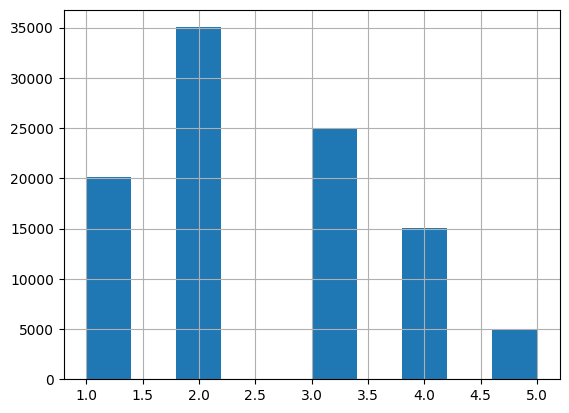

In [20]:
df['family_size'].hist()

<Axes: >

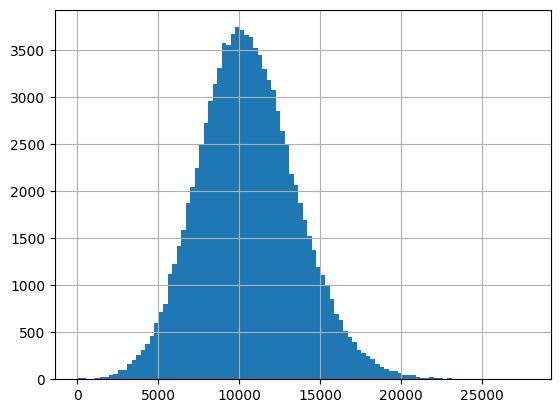

In [21]:
df['monthly_spending'].hist(bins=100)

<Axes: >

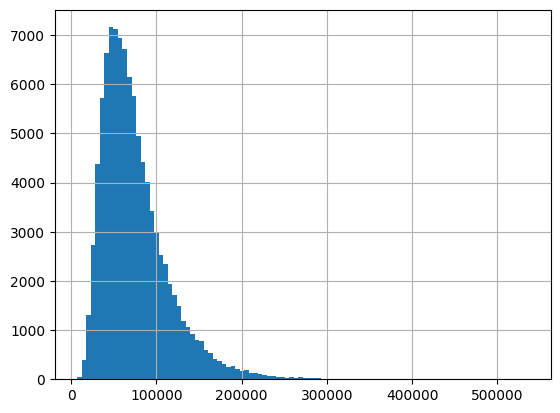

In [22]:
df['income'].hist(bins=100)

<Axes: >

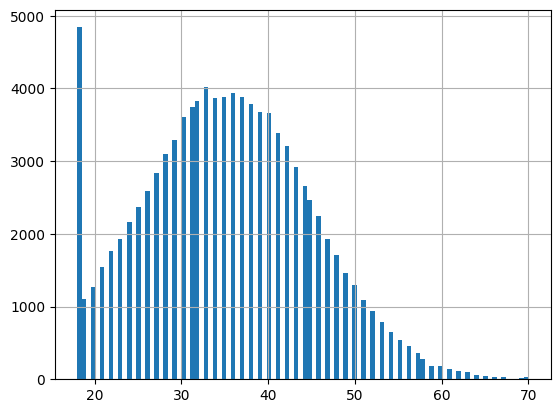

In [23]:
df['age'].hist(bins=100)

In [24]:
target_binary = pd.DataFrame({
    'target': [0.30, 0.70, 0.20],
    'actual': [np.mean(free_trial_banner), np.mean(urban_area), np.mean(remote_work)]
}, index = ['free_trial_banner', 'urban_area', 'remote_work'])
target_binary['abs_diff'] = np.abs(target_binary['actual'] - target_binary['target'])
target_binary

,target,actual,abs_diff
free_trial_banner,0.3,0.29958,0.00042
urban_area,0.7,0.69973,0.00027
remote_work,0.2,0.19968,0.00032


In [25]:
family_target = pd.Series({1: 0.20, 2: 0.35, 3: 0.25, 4: 0.15, 5: 0.05}, name = 'target')
family_actual = pd.Series(family_size).value_counts(normalize = True).sort_index()
family_check = pd.concat([family_target, family_actual.rename('actual')], axis = 1)
family_check['abs_diff'] = np.abs(family_check['actual'] - family_check['target'])
family_check

,target,actual,abs_diff
1,0.20,0.20158,0.00158
2,0.35,0.35039,0.00039
3,0.25,0.24891,0.00109
4,0.15,0.15045,0.00045
5,0.05,0.04867,0.00133


In [26]:
premium_by_banner = pd.crosstab(free_trial_banner,
                              premium_subscription,
                              normalize = 'index').rename(columns = {0: 'premium_0', 1: 'premium_1'})
premium_by_banner

col_0,premium_0,premium_1
row_0,,
0,0.828674,0.171326
1,0.590593,0.409407


In [27]:
type_table = pd.Series(ind_type).value_counts().to_frame('count')
type_table['share'] = type_table['count'] / n
type_table

,count,share
Never taker,59109,0.59109
Complier,23714,0.23714
Always taker,17177,0.17177


In [28]:
corr_table = pd.DataFrame(data = [np.corrcoef(premium_subscription, online_preference)[0, 1],
                                        np.corrcoef(premium_subscription, free_trial_banner)[0, 1]],
                          index = ['Corr(premium_subscription, online_preference)',
                                     'Corr(premium_subscription, free_trial_banner)'],
                          columns = ['estimate'])
corr_table

,estimate
"Corr(premium_subscription, online_preference)",0.221103
"Corr(premium_subscription, free_trial_banner)",0.254403


In [29]:
var_table = pd.DataFrame(data = [np.var(error0),   np.var(g0),
                                       np.var(g0_obs), np.var(g0_unobs),
                                       np.var(error1), np.var(g1),
                                       np.var(g1_obs), np.var(g1_unobs)],
                         index = ['Var(eps0)',   'Var(g0)',
                                    'Var(g0_obs)', 'Var(g0_unobs)',
                                    'Var(eps1)',   'Var(g1)',
                                    'Var(g1_obs)', 'Var(g1_unobs)'],
                         columns = ['estimate'])
var_table

,estimate
Var(eps0),2.592930e+06
Var(g0),4.348131e+06
Var(g0_obs),3.266419e+06
Var(g0_unobs),1.086454e+06
Var(eps1),2.240218e+06
Var(g1),5.500779e+06
Var(g1_obs),3.944596e+06
Var(g1_unobs),1.564494e+06


In [30]:
spending_checks = pd.DataFrame({
    'metric': ['share_zero_monthly_spending0', 'share_zero_monthly_spending1', 'mean_monthly_spending'],
    'value': [np.mean(monthly_spending0 == 0), np.mean(monthly_spending1 == 0), np.mean(monthly_spending)]
})
spending_checks

,metric,value
0,share_zero_monthly_spending0,0.000150
1,share_zero_monthly_spending1,0.000000
2,mean_monthly_spending,10540.787621


In [31]:
TE = monthly_spending1 - monthly_spending0
ATE = np.mean(TE)
LATE = np.mean(TE[ind_type == "Complier"])
CATE = g1 - g0
ATE_naive = np.mean(monthly_spending[premium_subscription == 1]) - np.mean(monthly_spending[premium_subscription == 0])

effect_table = pd.DataFrame({'estimate': [ATE, LATE, np.mean(CATE), ATE_naive]
                }, index = ['ATE', 'LATE', 'mean(CATE)', 'ATE_naive'])
effect_table

,estimate
ATE,2567.667930
LATE,2611.643789
mean(CATE),2579.053530
ATE_naive,3622.557482


In [32]:
df.isna().mean() * 100

monthly_spending        0.0
premium_subscription    0.0
income                  0.0
age                     0.0
urban_area              0.0
family_size             0.0
remote_work             0.0
free_trial_banner       0.0
dtype: float64